<a href="https://colab.research.google.com/github/lukmannm/data-science-2026/blob/main/Pertemuan9_Lukman_240401010181.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pertemuan 9: Klasifikasi Logistic Regression vs Decision Tree
*   Nama: Lukman Nur Hakim
*   NIM: 240401010181
*   Kelas: IF401
*   Mata Kuliah: Data Science
*   Dataset: Breast Cancer Wisconsin (dari sklearn)

##1. Load & EDA Singkat

In [ ]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # 0=malignant, 1=benign

print('Shape:', X.shape)
print('Distribusi target:')
print(pd.Series(y).value_counts(normalize=True).round(3))

Shape: (569, 30)
Distribusi target:
1    0.627
0    0.373
Name: proportion, dtype: float64


Dataset Breast Cancer Wisconsin berisi 569 sampel dengan 30 fitur numerik hasil pengukuran sel tumor.  
Target: 0 = Malignant (ganas), 1 = Benign (jinak).

##2. Preprocessing

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} baris, Test: {X_test.shape[0]} baris')

Train: 455 baris, Test: 114 baris


- Train-Test Split 80:20 dengan `stratify=y` agar proporsi kelas tetap seimbang di train dan test set
- StandardScaler di-fit hanya pada train set untuk mencegah data leakage
- Scaling wajib untuk Logistic Regression, opsional untuk Decision Tree

##3. Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train_s, y_train)
y_pred_log = log_model.predict(X_test_s)

coef_df = pd.DataFrame({
    'Fitur'     : X.columns,
    'Koefisien' : log_model.coef_[0]       # ← fix: coef_ bukan coef
}).sort_values('Koefisien', key=abs, ascending=False)

print(coef_df.head(10))

                   Fitur  Koefisien
21         worst texture  -1.255088
10          radius error  -1.082965
27  worst concave points  -0.953686
23            worst area  -0.947756
20          worst radius  -0.947616
28        worst symmetry  -0.939181
13            area error  -0.929104
26       worst concavity  -0.823151
22       worst perimeter  -0.763220
24      worst smoothness  -0.746625


Logistic Regression memprediksi probabilitas kelas menggunakan fungsi sigmoid.  
Koefisien positif → mendorong prediksi ke Benign, koefisien negatif → mendorong ke Malignant.

##4. Latih Decision Tree

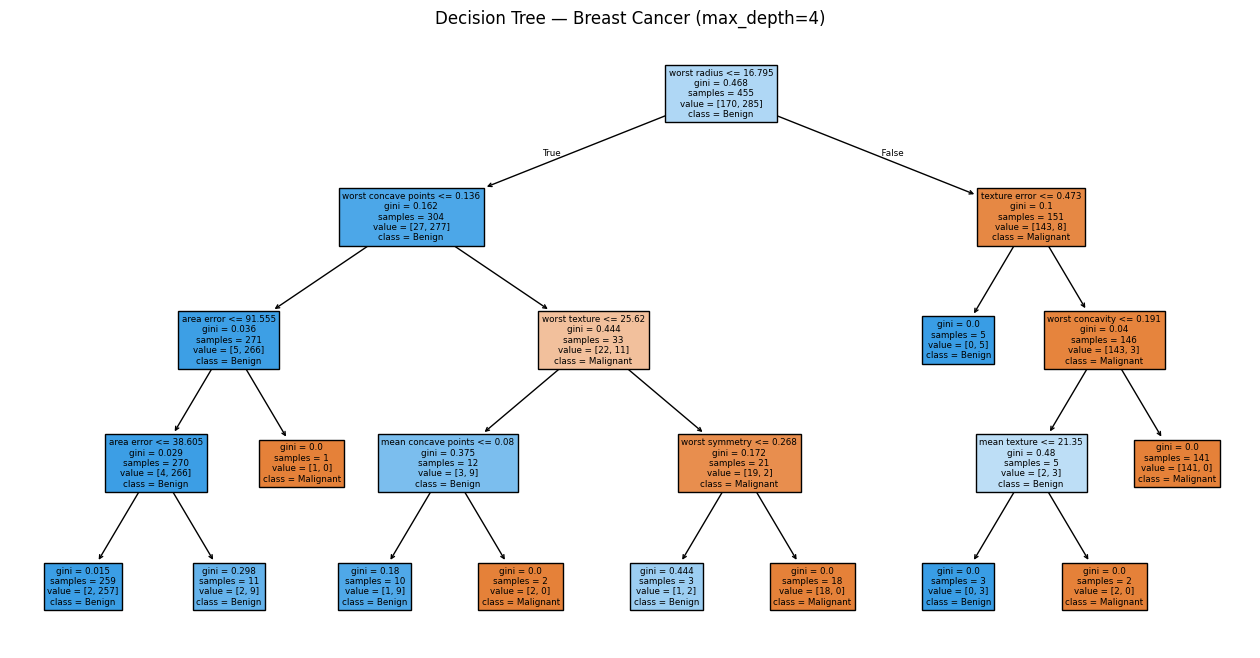

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

plt.figure(figsize=(16, 8))
plot_tree(tree_model,
          feature_names=X.columns,
          class_names=['Malignant', 'Benign'],
          filled=True)
plt.title('Decision Tree — Breast Cancer (max_depth=4)')
plt.show()

Decision Tree membagi data berdasarkan threshold fitur secara rekursif.  
max_depth=4 digunakan untuk mencegah overfitting.  
Decision Tree tidak memerlukan scaling karena bekerja berdasarkan urutan nilai, bukan jarak.

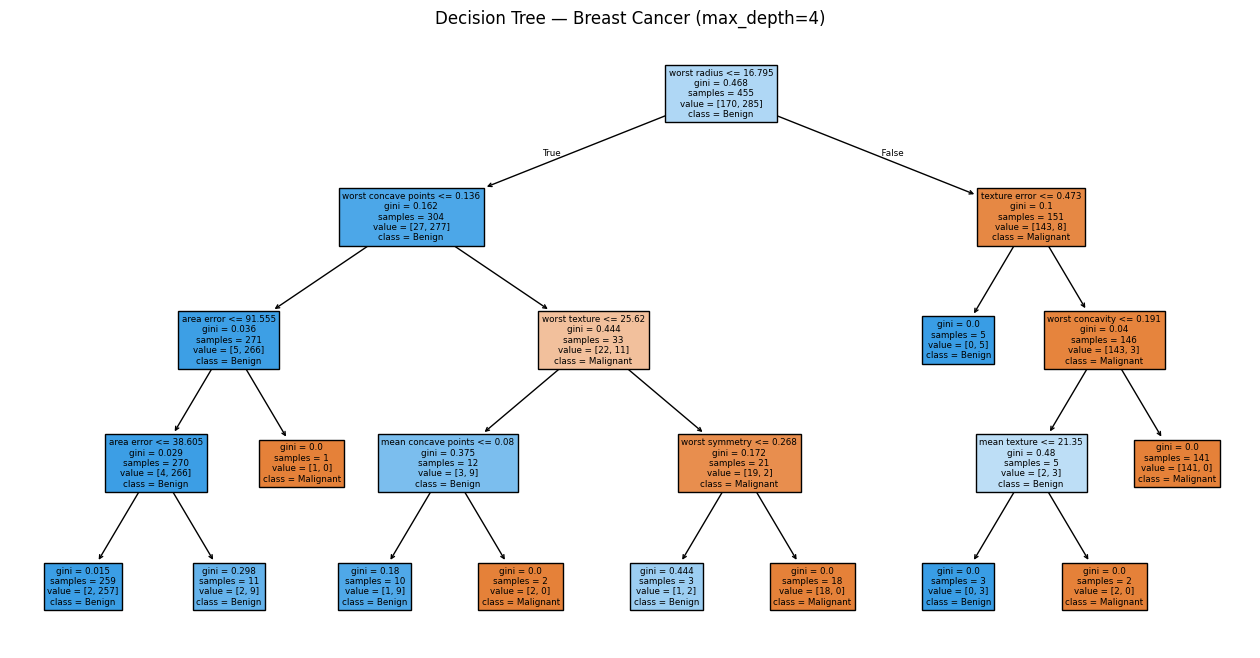

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

plt.figure(figsize=(16, 8))
plot_tree(tree_model,
          feature_names=X.columns,
          class_names=['Malignant', 'Benign'],
          filled=True)
plt.title('Decision Tree — Breast Cancer (max_depth=4)')
plt.show()

In [ ]:
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score)

for name, y_pred in [('Logistic Regression', y_pred_log),
                     ('Decision Tree',       y_pred_tree)]:
    print(f'\n=== {name} ===')
    print('Confusion Matrix:')
    print(confusion_matrix(y_test, y_pred))
    print(f'Accuracy : {accuracy_score(y_test,  y_pred):.3f}')
    print(f'Precision: {precision_score(y_test, y_pred):.3f}')
    print(f'Recall   : {recall_score(y_test,    y_pred):.3f}')
    print(f'F1-Score : {f1_score(y_test,        y_pred):.3f}')


=== Logistic Regression ===
Confusion Matrix:
[[41  1]
 [ 1 71]]
Accuracy : 0.982
Precision: 0.986
Recall   : 0.986
F1-Score : 0.986

=== Decision Tree ===
Confusion Matrix:
[[39  3]
 [ 4 68]]
Accuracy : 0.939
Precision: 0.958
Recall   : 0.944
F1-Score : 0.951


##5. Evaluasi & Perbandingan Model

| Metrik | Logistic Regression | Decision Tree |
|--------|-------------------|---------------|
| Accuracy | 0.982 | 0.939 |
| Precision | 0.986 | 0.958 |
| Recall | 0.986 | 0.944 |
| F1-Score | 0.986 | 0.951 |

**Model mana yang Recall-nya lebih tinggi?**  
Logistic Regression memiliki Recall lebih tinggi (0.986 vs 0.944).

**Mengapa Recall menjadi metrik paling kritis untuk diagnosis kanker?**  
Recall mengukur seberapa banyak kasus Malignant yang berhasil terdeteksi oleh model.  
False Negative (kanker tidak terdeteksi) jauh lebih berbahaya daripada False Positive (pasien sehat dikira sakit),
karena kanker yang terlewat berarti pasien tidak mendapat penanganan yang diperlukan.
Oleh karena itu, Recall lebih penting daripada Accuracy semata dalam konteks diagnosis medis.

**Apakah ada perbedaan signifikan antara kedua model?**  
Perbedaan performa kedua model cukup terlihat. Logistic Regression unggul di semua metrik,
dengan selisih Recall sebesar 0.042 (0.986 vs 0.944). Dalam konteks diagnosis kanker,
selisih ini cukup berarti karena artinya Decision Tree melewatkan 4 kasus Malignant
yang seharusnya terdeteksi. Logistic Regression lebih direkomendasikan untuk kasus ini.

## **Kesimpulan**

Dari kedua model yang diuji, Logistic Regression terbukti lebih unggul untuk kasus diagnosis kanker payudara ini.
Dengan Recall 0.986, model ini mampu mendeteksi hampir seluruh kasus Malignant dan meminimalkan risiko
kanker yang terlewat. Untuk aplikasi medis yang mengutamakan keselamatan pasien, Logistic Regression
menjadi pilihan yang lebih tepat dibanding Decision Tree.